QUESTION 1: K-Means from Scratch (2 Manual Iterations)
--- Initial Centroids: ---
C1: [3 3], C2: [3 7], C3: [9 4]


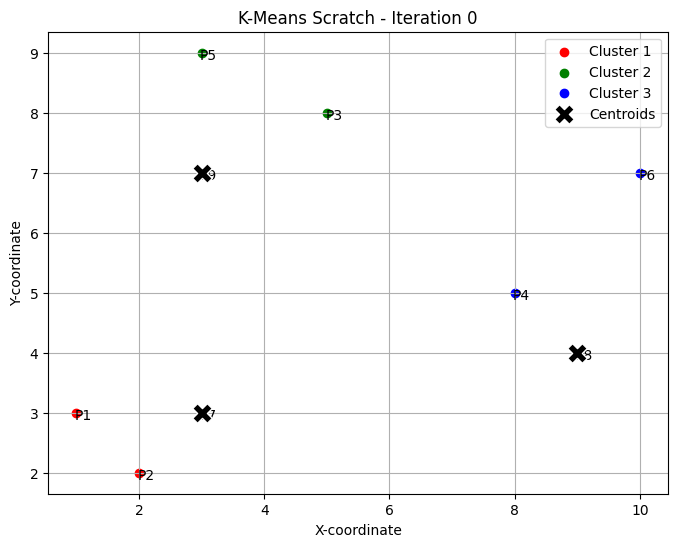


--- Iteration 1 Results ---
New Centroids:
C1: [2.         2.66666667]
C2: [3.66666667 8.        ]
C3: [9.         5.33333333]


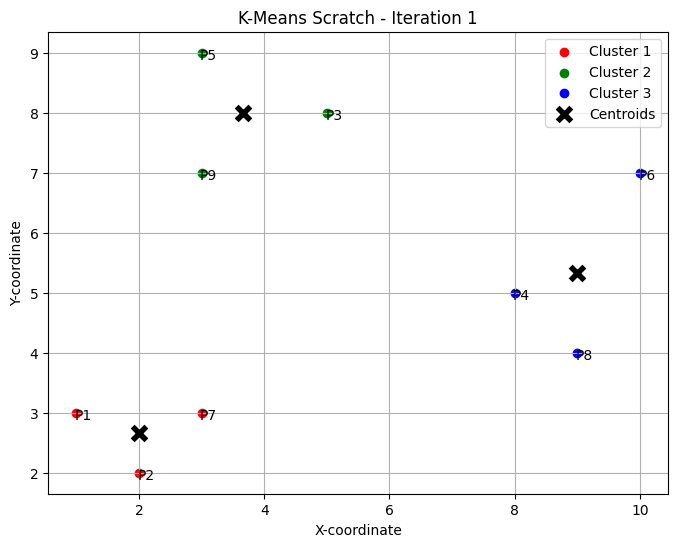


--- Iteration 2 Results ---
Final Centroids (After 2 Iterations):
C1: [2.         2.66666667]
C2: [3.66666667 8.        ]
C3: [9.         5.33333333]


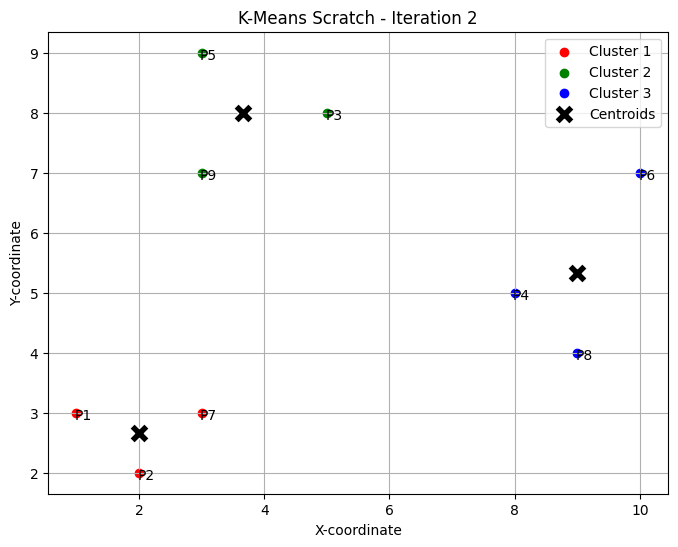


QUESTION 2: Scikit-learn K-Means (K=2, 3, 4)

--- Scikit-learn K-Means with K = 2 ---
Final Centroid Locations:
[[9.         5.33333333]
 [2.83333333 5.33333333]]
Number of points in each cluster: [3 6]


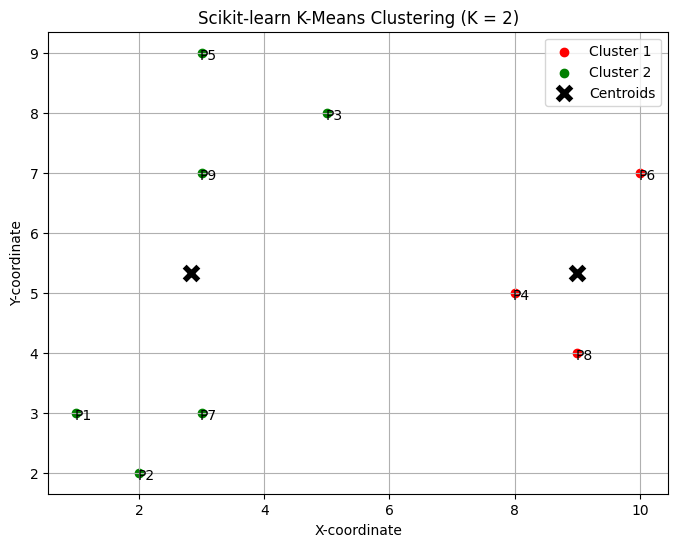


--- Scikit-learn K-Means with K = 3 ---
Final Centroid Locations:
[[9.         5.33333333]
 [3.66666667 8.        ]
 [2.         2.66666667]]
Number of points in each cluster: [3 3 3]


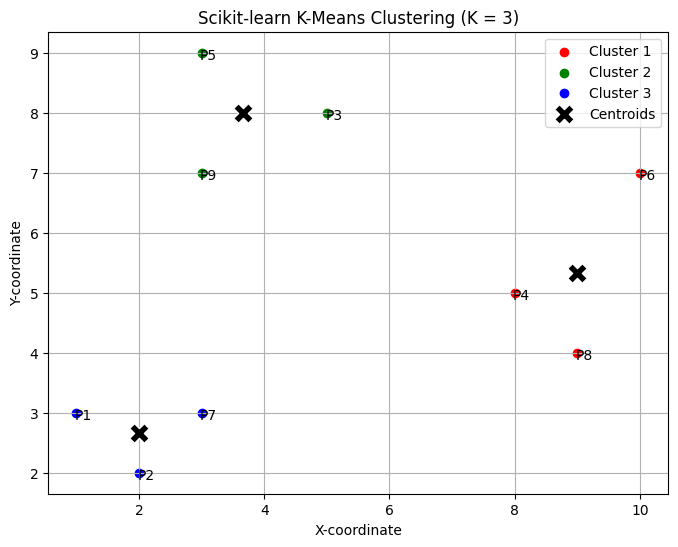


--- Scikit-learn K-Means with K = 4 ---
Final Centroid Locations:
[[ 8.5         4.5       ]
 [ 3.66666667  8.        ]
 [ 2.          2.66666667]
 [10.          7.        ]]
Number of points in each cluster: [2 3 3 1]


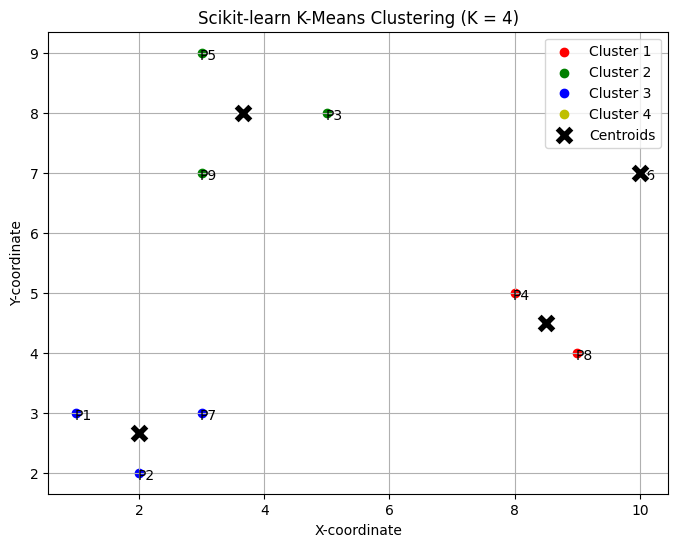


QUESTION 3: Add New Point P10(6, 2) and Re-Cluster
--- K-Means with New Point P10(6, 2) ---
P10(6, 2) joined Cluster: 2
Final Centroid Locations (10 points):
[[9.         5.33333333]
 [3.         2.5       ]
 [3.66666667 8.        ]]


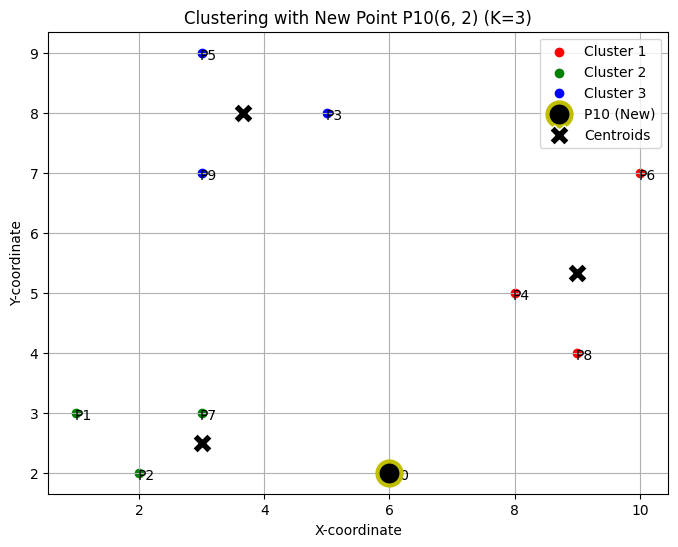


Explanation:
A new data point affects clustering by altering the mean of its assigned cluster.
P10(6, 2), being located in the lower-central region, pulls the closest centroid (likely Cluster 1) down and to the right, causing that cluster's boundary to shift.

QUESTION 4: Distance Table + First Iteration (Code Assisted)
--- Distance Table (First Assignment) ---
Point  Dist to C1  Dist to C2  Dist to C3 Assigned Cluster
   P1        2.00        4.47        8.06               C1
   P2        1.41        5.10        7.28               C1
   P3        5.39        2.24        5.66               C2
   P4        5.39        5.39        1.41               C3
   P5        6.00        2.00        7.81               C2
   P6        8.06        7.00        3.16               C3
   P7        0.00        4.00        6.08               C1
   P8        6.08        6.71        0.00               C3
   P9        4.00        0.00        6.71               C2

--- New Centroids (After First Iteration) --

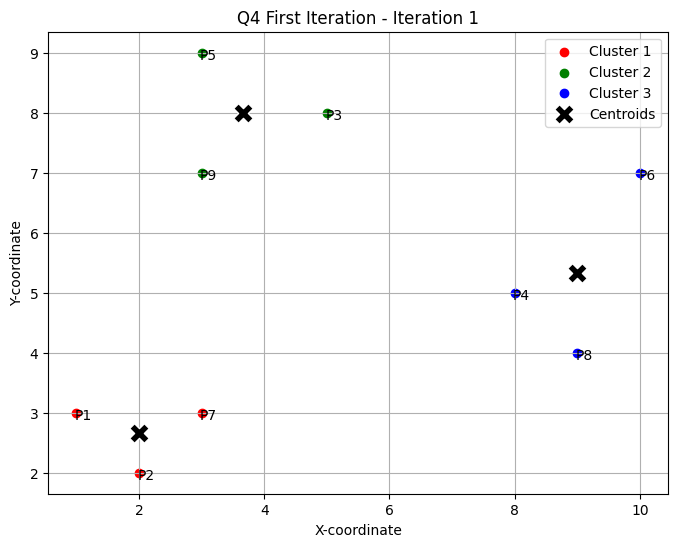

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd # Used for the distance table in Q4

# --- Global Data Definition ---
POINTS_9 = np.array([
    [1, 3], [2, 2], [5, 8], [8, 5], [3, 9],
    [10, 7], [3, 3], [9, 4], [3, 7]
])
POINT_LABELS_9 = [f'P{i+1}' for i in range(len(POINTS_9))]
K_VALUE = 3

# ==============================================================================
# QUESTION 1: K-Means from Scratch (Manual Iterations)
# ==============================================================================

print("="*60)
print("QUESTION 1: K-Means from Scratch (2 Manual Iterations)")
print("="*60)

# Initial Centroids (P7, P9, P8)
initial_centroids = np.array([
    POINTS_9[6],  # C1 = P7(3, 3)
    POINTS_9[8],  # C2 = P9(3, 7)
    POINTS_9[7]   # C3 = P8(9, 4)
])
current_centroids = initial_centroids.copy()

def euclidean_distance(a, b):
    """Computes the Euclidean distance between two points."""
    return np.sqrt(np.sum((a - b)**2))

def assign_clusters(data, centroids):
    """Assigns each data point to the nearest centroid."""
    assignments = []
    for point in data:
        dist_to_centroids = [euclidean_distance(point, c) for c in centroids]
        assignments.append(np.argmin(dist_to_centroids))
    return np.array(assignments)

def update_centroids(data, assignments, K):
    """Calculates the new mean center for each cluster."""
    new_centroids = []
    for k in range(K):
        cluster_points = data[assignments == k]
        if len(cluster_points) > 0:
            new_centroids.append(cluster_points.mean(axis=0))
        else:
            # Keep old centroid if cluster is empty
            new_centroids.append(current_centroids[k])
    return np.array(new_centroids)

def plot_clusters(data, assignments, centroids, iteration, title_prefix="K-Means Scratch"):
    """Plots the points, centroids, and cluster assignments."""
    plt.figure(figsize=(8, 6))
    colors = ['r', 'g', 'b', 'y', 'c', 'm']

    # Plot data points
    for i in range(K_VALUE):
        cluster_points = data[assignments == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    c=colors[i], label=f'Cluster {i+1}')

    # Plot centroids
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='X', s=200, c='k', label='Centroids', edgecolor='w', zorder=10)

    # Label all points
    for i, txt in enumerate(POINT_LABELS_9):
        plt.annotate(txt, (data[i, 0], data[i, 1]), textcoords="offset points", xytext=(5,-5), ha='center')

    plt.title(f'{title_prefix} - Iteration {iteration}')
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()

# -----------------
# Initial State (Iteration 0)
# -----------------
print("--- Initial Centroids: ---")
print(f"C1: {initial_centroids[0]}, C2: {initial_centroids[1]}, C3: {initial_centroids[2]}")
assignments_0 = assign_clusters(POINTS_9, initial_centroids)
plot_clusters(POINTS_9, assignments_0, initial_centroids, 0)


# -----------------
# Iteration 1
# -----------------
assignments_1 = assign_clusters(POINTS_9, current_centroids)
current_centroids = update_centroids(POINTS_9, assignments_1, K_VALUE)
print(f"\n--- Iteration 1 Results ---")
print(f"New Centroids:\nC1: {current_centroids[0]}\nC2: {current_centroids[1]}\nC3: {current_centroids[2]}")
plot_clusters(POINTS_9, assignments_1, current_centroids, 1)

# -----------------
# Iteration 2
# -----------------
assignments_2 = assign_clusters(POINTS_9, current_centroids)
current_centroids = update_centroids(POINTS_9, assignments_2, K_VALUE)
print(f"\n--- Iteration 2 Results ---")
print(f"Final Centroids (After 2 Iterations):\nC1: {current_centroids[0]}\nC2: {current_centroids[1]}\nC3: {current_centroids[2]}")
plot_clusters(POINTS_9, assignments_2, current_centroids, 2)


# ==============================================================================
# QUESTION 2: Scikit-learn K-Means (K=2, 3, 4)
# ==============================================================================

print("\n" + "="*60)
print("QUESTION 2: Scikit-learn K-Means (K=2, 3, 4)")
print("="*60)

def run_sklearn_kmeans(data, k_val, point_labels):
    """Runs Scikit-learn KMeans for a given K and plots the result."""
    # n_init='auto' and random_state for reproducibility
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    kmeans.fit(data)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    cluster_counts = np.bincount(labels)

    print(f"\n--- Scikit-learn K-Means with K = {k_val} ---")
    print(f"Final Centroid Locations:\n{centroids}")
    print(f"Number of points in each cluster: {cluster_counts}")

    # Plotting
    plt.figure(figsize=(8, 6))
    colors = ['r', 'g', 'b', 'y']

    for i in range(k_val):
        cluster_points = data[labels == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    c=colors[i], label=f'Cluster {i+1}')

    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='X', s=200, c='k', label='Centroids', edgecolor='w', zorder=10)

    # Label all points
    for i, txt in enumerate(point_labels):
        plt.annotate(txt, (data[i, 0], data[i, 1]), textcoords="offset points", xytext=(5,-5), ha='center')

    plt.title(f'Scikit-learn K-Means Clustering (K = {k_val})')
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run for K = 2, 3, 4
run_sklearn_kmeans(POINTS_9, 2, POINT_LABELS_9)
run_sklearn_kmeans(POINTS_9, 3, POINT_LABELS_9)
run_sklearn_kmeans(POINTS_9, 4, POINT_LABELS_9)


# ==============================================================================
# QUESTION 3: Add a New User Point and Re-Cluster (K=3)
# ==============================================================================

print("\n" + "="*60)
print("QUESTION 3: Add New Point P10(6, 2) and Re-Cluster")
print("="*60)

# New point P10(6, 2)
P10 = np.array([6, 2])
points_10 = np.vstack([POINTS_9, P10])
point_labels_10 = POINT_LABELS_9 + ['P10']

# Run K-Means on the 10 points
kmeans_q3 = KMeans(n_clusters=K_VALUE, random_state=42, n_init='auto')
kmeans_q3.fit(points_10)

labels_q3 = kmeans_q3.labels_
centroids_q3 = kmeans_q3.cluster_centers_

P10_cluster_index = labels_q3[-1]

print(f"--- K-Means with New Point P10(6, 2) ---")
print(f"P10(6, 2) joined Cluster: {P10_cluster_index + 1}")
print(f"Final Centroid Locations (10 points):\n{centroids_q3}")

# Plotting
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']

for i in range(K_VALUE):
    cluster_points = points_10[labels_q3 == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[i], label=f'Cluster {i+1}')

# Highlight P10
plt.scatter(P10[0], P10[1], marker='o', s=300, c='k', edgecolor='y', linewidth=3, label='P10 (New)', zorder=10)

plt.scatter(centroids_q3[:, 0], centroids_q3[:, 1],
            marker='X', s=200, c='k', label='Centroids', edgecolor='w', zorder=10)

# Label all points
for i, txt in enumerate(point_labels_10):
    plt.annotate(txt, (points_10[i, 0], points_10[i, 1]), textcoords="offset points", xytext=(5,-5), ha='center')

plt.title('Clustering with New Point P10(6, 2) (K=3)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.legend()
plt.grid(True)
plt.show()

print("\nExplanation:")
print("A new data point affects clustering by altering the mean of its assigned cluster.")
print("P10(6, 2), being located in the lower-central region, pulls the closest centroid (likely Cluster 1) down and to the right, causing that cluster's boundary to shift.")


# ==============================================================================
# QUESTION 4: Distance Table + First Iteration Manually (Code Assist)
# ==============================================================================

print("\n" + "="*60)
print("QUESTION 4: Distance Table + First Iteration (Code Assisted)")
print("="*60)

# Centroids for Q4 (same as initial for Q1)
C1_Q4 = np.array([3, 3])
C2_Q4 = np.array([3, 7])
C3_Q4 = np.array([9, 4])
centroids_Q4 = np.array([C1_Q4, C2_Q4, C3_Q4])

distances_Q4 = []
assignments_Q4 = []

# Compute distances and assignments
for i, point in enumerate(POINTS_9):
    dist_c1 = euclidean_distance(point, C1_Q4)
    dist_c2 = euclidean_distance(point, C2_Q4)
    dist_c3 = euclidean_distance(point, C3_Q4)

    dists = [dist_c1, dist_c2, dist_c3]
    assigned_cluster_index = np.argmin(dists)

    distances_Q4.append(dists)
    assignments_Q4.append(assigned_cluster_index)

# Create the Distance Table (DataFrame)
df_distances = pd.DataFrame(distances_Q4, columns=['Dist to C1', 'Dist to C2', 'Dist to C3'])
df_distances['Point'] = POINT_LABELS_9
df_distances['Assigned Cluster'] = [f'C{i+1}' for i in assignments_Q4]
df_distances = df_distances[['Point', 'Dist to C1', 'Dist to C2', 'Dist to C3', 'Assigned Cluster']]

# Highlight the minimum distance in each row
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: yellow' if v else '' for v in is_min]

# Display the table
print("--- Distance Table (First Assignment) ---")
print(df_distances.to_string(index=False, float_format="%.2f"))

# Calculate New Centroids (First Iteration)
assignments_Q4 = np.array(assignments_Q4)
new_centroids_Q4 = update_centroids(POINTS_9, assignments_Q4, K_VALUE)

print("\n--- New Centroids (After First Iteration) ---")
print(f"New C1: {new_centroids_Q4[0]} (Avg of P1, P2, P7)")
print(f"New C2: {new_centroids_Q4[1]} (Avg of P3, P5, P9)")
print(f"New C3: {new_centroids_Q4[2]} (Avg of P4, P6, P8)")

# Plot the First-Iteration Graph (Same as Q1, Iteration 1)
plot_clusters(POINTS_9, assignments_Q4, new_centroids_Q4, 1, title_prefix="Q4 First Iteration")